<a href="https://colab.research.google.com/github/leejuheon06/Practice_ML_1/blob/main/07_%EB%8B%A4%EC%A4%91_%EB%B6%84%EB%A5%98.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!sudo apt-get install -y fonts-nanum* | tail -n 1
!sudo fc-cache -fv
!rm -rf ~/.cache/matplotlib

debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 4.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 39 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no suc

In [2]:
# 필요 라이브러리 설치

!pip install torchviz | tail -n 1
!pip install torchinfo | tail -n 1

[런타임] -> [세션 다시 시작] 후 아래 셀 실행

In [132]:
# 라이브러리 임포트

%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# 폰트 관련 용도
import matplotlib.font_manager as fm

# 나눔 고딕 폰트의 경로 명시
path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_name = fm.FontProperties(fname=path, size=10).get_name()

In [133]:
# 파이토치 관련 라이브러리

import torch
import torch.nn as nn
import torch.optim as optim
from torchinfo import summary
from torchviz import make_dot

In [134]:
# 기본 폰트 설정
plt.rcParams['font.family'] = font_name

# 기본 폰트 사이즈 변경
plt.rcParams['font.size'] = 14

# 기본 그래프 사이즈 변경
plt.rcParams['figure.figsize'] = (6,6)

# 기본 그리드 표시
# 필요에 따라 설정할 때는, plt.grid()
plt.rcParams['axes.grid'] = True

# 마이너스 기호 정상 출력
plt.rcParams['axes.unicode_minus'] = False

# 넘파이 부동소수점 자릿수 표시
np.set_printoptions(suppress=True, precision=4)

7.8 데이터 준비

In [135]:
# 학습용 데이터 준비

# 라이브러리 임포트
from sklearn.datasets import load_iris

# 데이터 불러오기
iris = load_iris()

# 입력 데이터와 정답 데이터
x_org, y_org = iris.data, iris.target

# 결과 확인
print('원본 데이터', x_org.shape, y_org.shape)

# 데이터 추출

# 입력 데이터로 sepal(꽃받침) length(0)와 petal(꽃잎) length(2)를 추출
x_select = x_org[:,[0,2]]

# 결과 확인
print('원본 데이터', x_select.shape, y_org.shape)

원본 데이터 (150, 4) (150,)
원본 데이터 (150, 2) (150,)


In [136]:
# 훈련 데이터와 검증 데이터로 분할
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x_select, y_org, train_size=75, test_size=75, random_state=123)
print(x_train.shape, x_test.shape, y_train.shape, y_test.shape)

(75, 2) (75, 2) (75,) (75,)


In [137]:
x_train

array([[6.3, 4.7],
       [7. , 4.7],
       [5. , 1.6],
       [6.4, 5.6],
       [6.3, 5. ],
       [5. , 1.6],
       [4.9, 1.4],
       [6.1, 4. ],
       [6.5, 4.6],
       [6.3, 6. ],
       [5.8, 1.2],
       [4.6, 1.4],
       [5.5, 3.8],
       [5. , 1.6],
       [5.9, 4.8],
       [6.9, 5.4],
       [4.8, 1.6],
       [6.7, 5.8],
       [5.7, 1.5],
       [5.7, 1.7],
       [6.7, 5. ],
       [4.6, 1. ],
       [5.4, 1.5],
       [6.6, 4.6],
       [7.3, 6.3],
       [6.6, 4.4],
       [5.6, 3.6],
       [5.6, 3.9],
       [4.6, 1.5],
       [5. , 1.3],
       [6.8, 4.8],
       [6.1, 5.6],
       [4.9, 1.5],
       [5.2, 1.5],
       [5.6, 4.2],
       [6. , 4.5],
       [6.2, 4.3],
       [7.1, 5.9],
       [6.9, 4.9],
       [5.8, 4. ],
       [5.7, 4.1],
       [7.6, 6.6],
       [5. , 1.5],
       [5.3, 1.5],
       [5.9, 4.2],
       [6.9, 5.7],
       [6.4, 5.5],
       [7.2, 6. ],
       [6.5, 5.2],
       [5.1, 1.5],
       [5.4, 4.5],
       [4.7, 1.3],
       [5.8,

In [138]:
# 데이터를 정답별로 분할

x_t0 = x_train[y_train == 0]
x_t1 = x_train[y_train == 1]
x_t2 = x_train[y_train == 2]

In [139]:
print(x_t0[:5])
print(x_t1[:5])
print(x_t2[:5])

[[5.  1.6]
 [5.  1.6]
 [4.9 1.4]
 [5.8 1.2]
 [4.6 1.4]]
[[6.3 4.7]
 [7.  4.7]
 [6.1 4. ]
 [6.5 4.6]
 [5.5 3.8]]
[[6.4 5.6]
 [6.3 5. ]
 [6.3 6. ]
 [6.9 5.4]
 [6.7 5.8]]


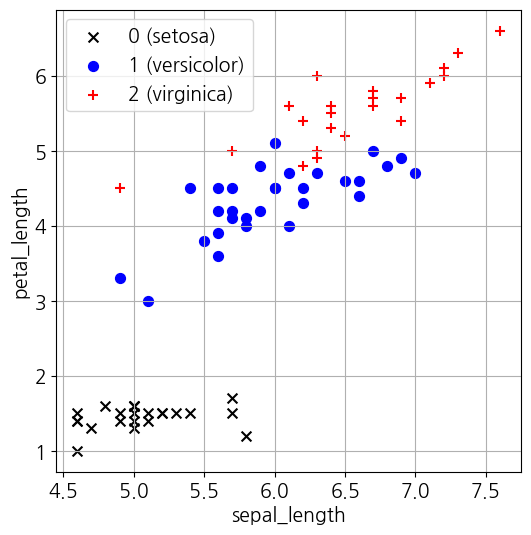

In [140]:
# 산포도 출력
# 실데이터 분포 확인 > 어떤 변수끼리 상관관계가 있나 확인

plt.scatter(x_t0[:,0], x_t0[:,1], marker='x', c='k', s=50, label='0 (setosa)')
plt.scatter(x_t1[:,0], x_t1[:,1], marker='o', c='b', s=50, label='1 (versicolor)')
plt.scatter(x_t2[:,0], x_t2[:,1], marker='+', c='r', s=50, label='2 (virginica)')
plt.xlabel('sepal_length')
plt.ylabel('petal_length')
plt.legend()
plt.show()

7.9 모델 정의

In [141]:
# 학습용 파라미터 설정

# 입력 차원수
n_input = x_train.shape[1]

# 출력 차원수
n_output = len(list(set(y_train)))

# 결과 확인
print(f'n_input: {n_input} n_output: {n_output}')

n_input: 2 n_output: 3


In [142]:
# 모델 정의
class Net(nn.Module):
    def __init__(self, n_input, n_output):
        super().__init__()
        self.l1 = nn.Linear(n_input, n_output)

        self.l1.weight.data.fill_(1.0)
        self.l1.bias.data.fill_(1.0)

    def forward(self, x):
        x1 = self.l1(x)
        return x1

In [143]:
# 인스턴스 생성
net = Net(n_input, n_output)

In [144]:
print(net)

Net(
  (l1): Linear(in_features=2, out_features=3, bias=True)
)


In [145]:
# 모델 개요 표시 1

print(summary(net))

Layer (type:depth-idx)                   Param #
Net                                      --
├─Linear: 1-1                            9
Total params: 9
Trainable params: 9
Non-trainable params: 0


In [146]:
# 모델 개요 표시 2

summary(net, (2,))
# (2, ) : 모델에 들어갈 데이터 입력 크기 (shape)
# >> 2 : 입력 feature 개수가 2개

Layer (type:depth-idx)                   Output Shape              Param #
Net                                      [3]                       --
├─Linear: 1-1                            [3]                       9
Total params: 9
Trainable params: 9
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

In [147]:
for parameter in net.named_parameters():
    print((parameter))

('l1.weight', Parameter containing:
tensor([[1., 1.],
        [1., 1.],
        [1., 1.]], requires_grad=True))
('l1.bias', Parameter containing:
tensor([1., 1., 1.], requires_grad=True))


In [148]:
# 손실 함수
criterion = nn.CrossEntropyLoss()

# 학습률
lr = 0.01

# 최적호 함수 : 경사 하강법
optimizer = optim.SGD(net.parameters(), lr=lr)

In [149]:
# 훈련용 입력, 출력 데이터 텐서화
inputs = torch.tensor(x_train).float()
labels = torch.tensor(y_train).long()

# 검증용 입력, 출력 데이터 텐서화
inputs_test = torch.tensor(x_test).float()
labels_test = torch.tensor(y_test).long()

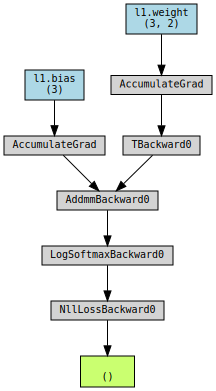

In [150]:
# 예측 계산
outputs = net(inputs)

# 손실 계산
loss = criterion(outputs, labels)

# 손실 그래프 시각화
g = make_dot(loss, params=dict(net.named_parameters()))
display(g)

In [151]:
# 예측 라벨 확인
torch.max(outputs)
# 텐서 전체 값 중에 가장 큰 값

tensor(15.2000, grad_fn=<MaxBackward1>)

In [152]:
# torch.max 함수 호출
# 반환 값 구조 (values, indices)
# 2번째 인수는 축을 의미, 1이면 행별로 집계
print(torch.max(outputs, 1))

torch.return_types.max(
values=tensor([12.0000, 12.7000,  7.6000, 13.0000, 12.3000,  7.6000,  7.3000, 11.1000,
        12.1000, 13.3000,  8.0000,  7.0000, 10.3000,  7.6000, 11.7000, 13.3000,
         7.4000, 13.5000,  8.2000,  8.4000, 12.7000,  6.6000,  7.9000, 12.2000,
        14.6000, 12.0000, 10.2000, 10.5000,  7.1000,  7.3000, 12.6000, 12.7000,
         7.4000,  7.7000, 10.8000, 11.5000, 11.5000, 14.0000, 12.8000, 10.8000,
        10.8000, 15.2000,  7.5000,  7.8000, 11.1000, 13.6000, 12.9000, 14.2000,
        12.7000,  7.6000, 10.9000,  7.0000, 10.9000, 11.2000,  7.4000, 11.7000,
        13.3000, 11.5000, 13.4000, 12.7000,  7.7000, 11.8000,  7.0000, 12.6000,
        11.7000, 10.9000,  9.2000, 12.2000, 10.4000, 12.1000,  7.5000,  9.1000,
        11.1000, 12.0000, 14.3000], grad_fn=<MaxBackward0>),
indices=tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 

In [153]:
print(torch.max(outputs, 0))
# 2번째 인수는 0번째 차원(세로방향, 배치 데이터 전체)
# 각 클래스 별로 이번 배치 데이터 중에서 가장 높은 점수 얼마야?

print()
print(torch.max(outputs, 0)[0])
print()
print(torch.max(outputs, 0)[1])

torch.return_types.max(
values=tensor([15.2000, 15.2000, 15.2000], grad_fn=<MaxBackward0>),
indices=tensor([41, 41, 41]))

tensor([15.2000, 15.2000, 15.2000], grad_fn=<MaxBackward0>)

tensor([41, 41, 41])


In [154]:
print(torch.max(outputs, 1)[0])  # values
print()
print(torch.max(outputs, 1)[1])  # indices

tensor([12.0000, 12.7000,  7.6000, 13.0000, 12.3000,  7.6000,  7.3000, 11.1000,
        12.1000, 13.3000,  8.0000,  7.0000, 10.3000,  7.6000, 11.7000, 13.3000,
         7.4000, 13.5000,  8.2000,  8.4000, 12.7000,  6.6000,  7.9000, 12.2000,
        14.6000, 12.0000, 10.2000, 10.5000,  7.1000,  7.3000, 12.6000, 12.7000,
         7.4000,  7.7000, 10.8000, 11.5000, 11.5000, 14.0000, 12.8000, 10.8000,
        10.8000, 15.2000,  7.5000,  7.8000, 11.1000, 13.6000, 12.9000, 14.2000,
        12.7000,  7.6000, 10.9000,  7.0000, 10.9000, 11.2000,  7.4000, 11.7000,
        13.3000, 11.5000, 13.4000, 12.7000,  7.7000, 11.8000,  7.0000, 12.6000,
        11.7000, 10.9000,  9.2000, 12.2000, 10.4000, 12.1000,  7.5000,  9.1000,
        11.1000, 12.0000, 14.3000], grad_fn=<MaxBackward0>)

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

In [155]:
# 반복 계산

# 학습률
lr = 0.01

# 초기화
net = Net(n_input, n_output)

# 손실 함수 : 교차 엔트로피 함수
criterion = nn.CrossEntropyLoss()

# 최적화 함수
optimizer = optim.SGD(net.parameters(), lr=lr)

# 반복 횟수
num_epochs = 10000

# 기록
history = np.zeros((0,5))

In [156]:
# 반복 계산 메인 루프 (훈련)
for epoch in range(num_epochs):
    # 훈련(학습)
    optimizer.zero_grad()
    outputs = net(inputs)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()

    # 예측 라벨 산출
    predicted = torch.max(outputs, 1)[1]

    # 손실과 정확도 계산
    train_loss = loss.item()
    train_acc = (predicted == labels).sum() / len(labels)

    # 예측
    outputs_test = net(inputs_test)
    loss_test = criterion(outputs_test, labels_test)
    predicted_test = torch.max(outputs_test, 1)[1]

    # 손실 정확도 계산
    val_loss = loss_test.item()
    val_acc = (predicted_test == labels_test).sum() / len(labels_test)

    if ((epoch + 1) % 1000 == 0):
        print(f'Epoch [{epoch+1}/{num_epochs}], loss: {train_loss:.5f}, acc: {train_acc:.5f}, val_loss: {val_loss:.5f}, val_acc: {val_acc:.5f}')
        item = np.array([epoch, train_loss, train_acc, val_loss, val_acc])
        history = np.vstack((history, item))


Epoch [1000/10000], loss: 0.45470, acc: 0.89333, val_loss: 0.44146, val_acc: 0.92000
Epoch [2000/10000], loss: 0.36875, acc: 0.90667, val_loss: 0.35483, val_acc: 0.94667
Epoch [3000/10000], loss: 0.32141, acc: 0.90667, val_loss: 0.30717, val_acc: 0.94667
Epoch [4000/10000], loss: 0.29054, acc: 0.90667, val_loss: 0.27584, val_acc: 0.96000
Epoch [5000/10000], loss: 0.26881, acc: 0.90667, val_loss: 0.25356, val_acc: 0.96000
Epoch [6000/10000], loss: 0.25270, acc: 0.90667, val_loss: 0.23688, val_acc: 0.96000
Epoch [7000/10000], loss: 0.24031, acc: 0.90667, val_loss: 0.22392, val_acc: 0.96000
Epoch [8000/10000], loss: 0.23047, acc: 0.90667, val_loss: 0.21353, val_acc: 0.96000
Epoch [9000/10000], loss: 0.22248, acc: 0.90667, val_loss: 0.20502, val_acc: 0.96000
Epoch [10000/10000], loss: 0.21584, acc: 0.90667, val_loss: 0.19789, val_acc: 0.96000


7.11 결과 확인

In [157]:
# 예측 손실과 정확도 확인
print(f'초기상태 : 손실 : {history[0,3]:.5f} 정확도 : {history[0,4]:.5f}')
print(f'최종상태 : 손실 : {history[-1,3]:.5f} 정확도 : {history[-1,4]:.5f}')

초기상태 : 손실 : 0.44146 정확도 : 0.92000
최종상태 : 손실 : 0.19789 정확도 : 0.96000


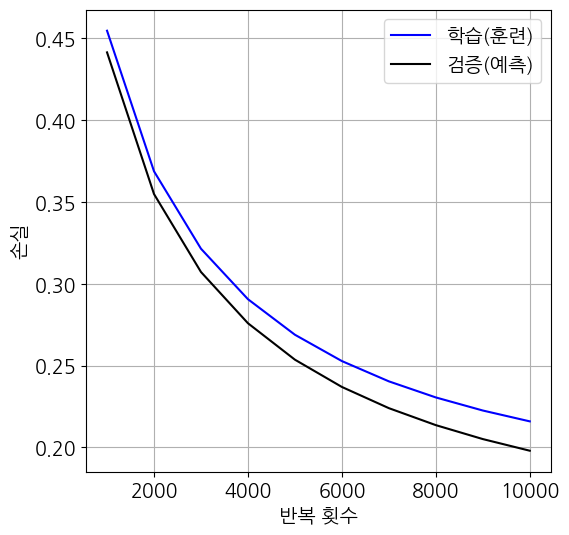

In [158]:
# 학습 곡선 출력(손실)

plt.plot(history[:,0], history[:,1], c='b', label='학습(훈련)')
plt.plot(history[:,0], history[:,3], c='k', label='검증(예측)')
plt.xlabel('반복 횟수')
plt.ylabel('손실')
plt.legend()
plt.show()

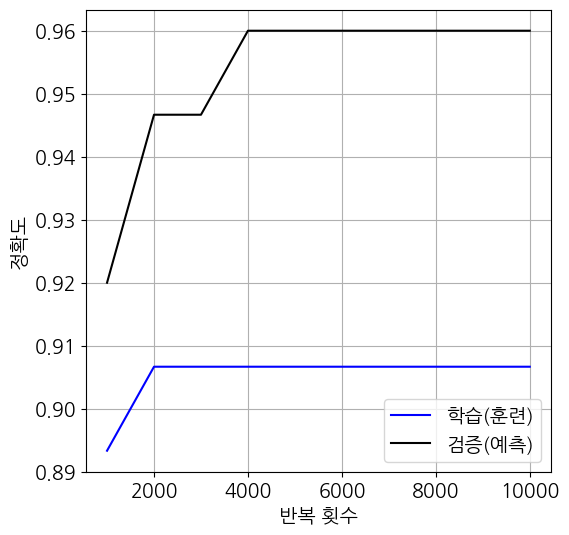

In [159]:
# 학습 곡선 출력(정확도)

plt.plot(history[:,0], history[:,2], c='b', label='학습(훈련)')
plt.plot(history[:,0], history[:,4], c='k', label='검증(예측)')
plt.xlabel('반복 횟수')
plt.ylabel('정확도')
plt.legend()
plt.show()

In [160]:
# 해석하는 방법
# loss: 0.22247 acc: 0.90667 val_loss: 0.20501, val_acc: 0.96000
# 과소적합을 의심 : n을 늘려야 함. 연구대상 샘플이 너무 적어서 학습 효과가 안나오는 경우
# >> 훈련할때는 0.90(90%) 정도인데 실제 검증데이터, 즉 새로운 데이터에서는 0.96(96%) 보임
# 반대로 학습한 결과의 정확도인 acc 가 0.99인데 val_acc 가 0.86으로 심하게 차이가 날 경우, 과적합 의심
# >> 반복 훈련한 결과가 과적합 되어 일반화가 안되었다고 해석함

In [161]:
# 정답 데이터 0, 1, 2에 해당하는 샘플 각각 추출
print('--- 모델 출력값 확인 ---')
indices_to_check = [0, 2, 3]
print(f'확인할 샘플의 정답 레이블: {labels[indices_to_check].numpy()}')

--- 모델 출력값 확인 ---
확인할 샘플의 정답 레이블: [1 0 2]


In [162]:
labels[indices_to_check]

tensor([1, 0, 2])

In [163]:
# 해당 입력값 추출
i3 = inputs[indices_to_check, :]
print(f'해당 입력값:\n{i3.data.numpy()}')

해당 입력값:
[[6.3 4.7]
 [5.  1.6]
 [6.4 5.6]]


In [164]:
# 소프트맥스 함수 정의 및 적용
softmax = torch.nn.Softmax(dim=1)
# 배치의 각 샘플에 대해 클래스 차원
o3 = net(i3)
k3 = softmax(o3) # 확률값 변환

print(f'\n모델의 원시 출력 (logits):\n{o3.data.numpy()}')
print(f'소프트맥스 적용 후 확률:\n{k3.data.numpy()}')


모델의 원시 출력 (logits):
[[ 8.8071 14.1937 12.9986]
 [12.8262  9.8     0.1734]
 [ 6.7954 15.0928 17.1111]]
소프트맥스 적용 후 확률:
[[0.0035 0.765  0.2315]
 [0.9537 0.0463 0.    ]
 [0.     0.1173 0.8827]]


In [165]:
# 가중치 행렬
print(f'가중치 행렬:\n{net.l1.weight.data}')
# 편향
print(f'편향:\n{net.l1.bias.data}')

가중치 행렬:
tensor([[ 3.0452, -2.5735],
        [ 1.3573,  0.8481],
        [-1.4026,  4.7253]])
편향:
tensor([ 1.7178,  1.6563, -0.3741])


7.12 입력 변수의 4차원화

In [166]:
# 훈련 데이터와 검증 데이터로 분할(셔플도 동시에 실시함)

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x_org, y_org, train_size=75, test_size=75,
    random_state=123)
print(x_train.shape, x_test.shape, y_train.shape, y_test.shape)

# 입력 차원수
n_input = x_train.shape[1]

(75, 4) (75, 4) (75,) (75,)


In [167]:
print('입력 데이터(x)')
print(x_train[:5,:])
print(f'입력 차원수: {n_input}')

입력 데이터(x)
[[6.3 3.3 4.7 1.6]
 [7.  3.2 4.7 1.4]
 [5.  3.  1.6 0.2]
 [6.4 2.8 5.6 2.1]
 [6.3 2.5 5.  1.9]]
입력 차원수: 4


In [168]:
# 입력 데이터 x_train과 정답 데이터 y_train의 텐서 변수화
inputs = torch.tensor(x_train).float()
labels = torch.tensor(y_train).long()

# 검증용 데이터의 텐서 변수화
inputs_test = torch.tensor(x_test).float()
labels_test = torch.tensor(y_test).long()

In [169]:
# 학습률
lr = 0.01

# 초기화
net = Net(n_input, n_output)

# 손실 함수： 교차 엔트로피 함수
criterion = nn.CrossEntropyLoss()

# 최적화 알고리즘: 경사 하강법
optimizer = optim.SGD(net.parameters(), lr=lr)

# 반복 횟수
num_epochs = 10000

# 평가 결과 기록
history = np.zeros((0,5))

In [170]:
# 반복 계산 메인 루프 (훈련)
for epoch in range(num_epochs):
    # 훈련(학습)
    optimizer.zero_grad()
    outputs = net(inputs)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()

    # 예측 라벨 산출
    predicted = torch.max(outputs, 1)[1]

    # 손실과 정확도 계산
    train_loss = loss.item()
    train_acc = (predicted == labels).sum() / len(labels)

    # 예측
    outputs_test = net(inputs_test)
    loss_test = criterion(outputs_test, labels_test)
    predicted_test = torch.max(outputs_test, 1)[1]

    # 손실 정확도 계산
    test_loss = loss_test.item()
    test_acc = (predicted_test == labels_test).sum() /len(labels_test)

    if ((epoch % 1000) == 0):
        print(f'Epoch [{epoch+1}/{num_epochs}] train_loss: {train_loss:.5f}, train_acc: {train_acc:.5f}, test_loss: {test_loss:.5f}, test_acc: {test_acc:.5f}')
        item = np.array([epoch, train_loss, train_acc, test_loss, test_acc])
        history = np.vstack([history, item])

Epoch [1/10000] train_loss: 1.09861, train_acc: 0.30667, test_loss: 1.09158, test_acc: 0.26667
Epoch [1001/10000] train_loss: 0.37106, train_acc: 0.97333, test_loss: 0.36017, test_acc: 0.96000
Epoch [2001/10000] train_loss: 0.27799, train_acc: 0.97333, test_loss: 0.27252, test_acc: 0.96000
Epoch [3001/10000] train_loss: 0.22870, train_acc: 0.98667, test_loss: 0.22713, test_acc: 0.96000
Epoch [4001/10000] train_loss: 0.19802, train_acc: 0.98667, test_loss: 0.19931, test_acc: 0.96000
Epoch [5001/10000] train_loss: 0.17703, train_acc: 0.98667, test_loss: 0.18053, test_acc: 0.96000
Epoch [6001/10000] train_loss: 0.16172, train_acc: 0.98667, test_loss: 0.16700, test_acc: 0.96000
Epoch [7001/10000] train_loss: 0.15003, train_acc: 0.98667, test_loss: 0.15680, test_acc: 0.96000
Epoch [8001/10000] train_loss: 0.14078, train_acc: 0.98667, test_loss: 0.14883, test_acc: 0.96000
Epoch [9001/10000] train_loss: 0.13327, train_acc: 0.98667, test_loss: 0.14243, test_acc: 0.96000


In [171]:
# 예측 손실과 정확도 확인
print(f'초기상태 : 손실 : {history[0,3]:.5f} 정확도 : {history[0,4]:.5f}')
print(f'최종상태 : 손실 : {history[-1,3]:.5f} 정확도 : {history[-1,4]:.5f}')

초기상태 : 손실 : 1.09158 정확도 : 0.26667
최종상태 : 손실 : 0.14243 정확도 : 0.96000


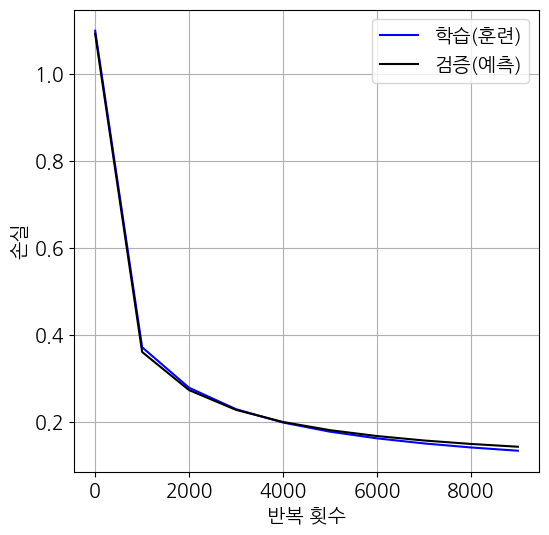

In [172]:
# 학습 곡선 출력(손실)

plt.plot(history[:,0], history[:,1], c='b', label='학습(훈련)')
plt.plot(history[:,0], history[:,3], c='k', label='검증(예측)')
plt.xlabel('반복 횟수')
plt.ylabel('손실')
plt.legend()
plt.show()

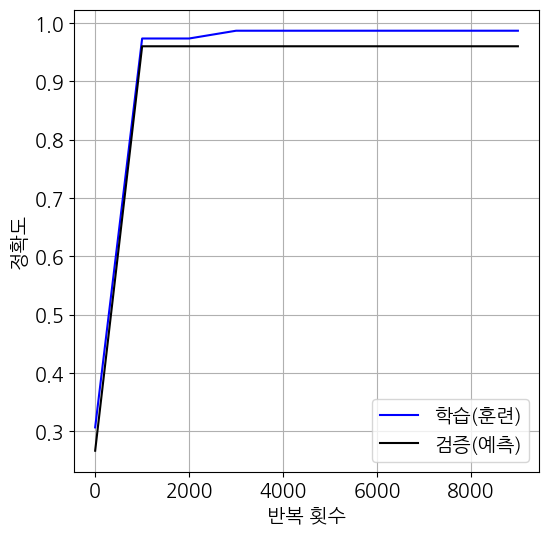

In [173]:
# 학습 곡선 출력(정확도)

plt.plot(history[:,0], history[:,2], c='b', label='학습(훈련)')
plt.plot(history[:,0], history[:,4], c='k', label='검증(예측)')
plt.xlabel('반복 횟수')
plt.ylabel('정확도')
plt.legend()
plt.show()

In [173]:
# eos